# Distribution Analysis

Phân tích phân phối dữ liệu chi tiết và xử lý outliers cho các biến số

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest

In [2]:
# Load cleaned data
df = pd.read_csv('data/youtube_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']

## 1. Normality Tests

Kiểm tra xem các biến có phân phối chuẩn (normal distribution) hay không.

In [3]:
# Test normality cho tất cả các biến số
normality_results = []

for col in numerical_cols:
    # Shapiro-Wilk Test
    stat_shapiro, p_shapiro = shapiro(df[col].dropna().sample(min(5000, len(df))))
    
    # Kolmogorov-Smirnov Test
    stat_ks, p_ks = kstest(df[col].dropna(), 'norm')
    
    normality_results.append({
        'Variable': col,
        'Shapiro-Wilk p-value': round(p_shapiro, 6),
        'KS p-value': round(p_ks, 6),
        'Is Normal (α=0.05)': 'Yes' if p_shapiro > 0.05 and p_ks > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)
normality_df

,Variable,Shapiro-Wilk p-value,KS p-value,Is Normal (α=0.05)
0,duration,0.0,0.0,No
1,bitrate,0.0,0.0,No
2,bitrate(video),0.0,0.0,No
3,height,0.0,0.0,No
4,width,0.0,0.0,No
5,frame rate,0.0,0.0,No
6,frame rate(est.),0.0,0.0,No
7,views,0.0,0.0,No
8,likes,0.0,0.0,No
9,comments,0.0,0.0,No


## 2. Outlier Detection

Phát hiện outliers sử dụng IQR method và Z-score method.

In [4]:
# Hàm phát hiện outliers bằng IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Hàm phát hiện outliers bằng Z-score
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column].dropna()))
    outliers_idx = np.where(z_scores > threshold)[0]
    return data.iloc[outliers_idx]

# Phân tích outliers cho từng biến
outlier_summary = []

for col in numerical_cols:
    outliers_iqr, lower, upper = detect_outliers_iqr(df, col)
    outliers_z = detect_outliers_zscore(df, col)
    
    outlier_summary.append({
        'Variable': col,
        'Total Records': len(df),
        'Outliers (IQR)': len(outliers_iqr),
        'Outliers (Z-score)': len(outliers_z),
        'Outlier % (IQR)': round(len(outliers_iqr) / len(df) * 100, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Total Records,Outliers (IQR),Outliers (Z-score),Outlier % (IQR),Lower Bound,Upper Bound
0,duration,17586,1374,210,7.81,-274.50,593.50
1,bitrate,17586,2671,610,15.19,-847.00,2577.00
2,bitrate(video),17586,2603,614,14.80,-946.00,2462.00
3,height,17586,1366,3,7.77,-375.00,1761.00
4,width,17586,57,57,0.32,-280.00,1320.00
5,frame rate,17586,2287,403,13.00,17.55,37.42
6,frame rate(est.),17586,0,0,0.00,-37.50,62.50
7,views,17586,2888,8,16.42,-1105.00,1943.00
8,likes,17586,2565,10,14.59,-6.00,10.00
9,comments,17586,2424,62,13.78,-1.50,2.50


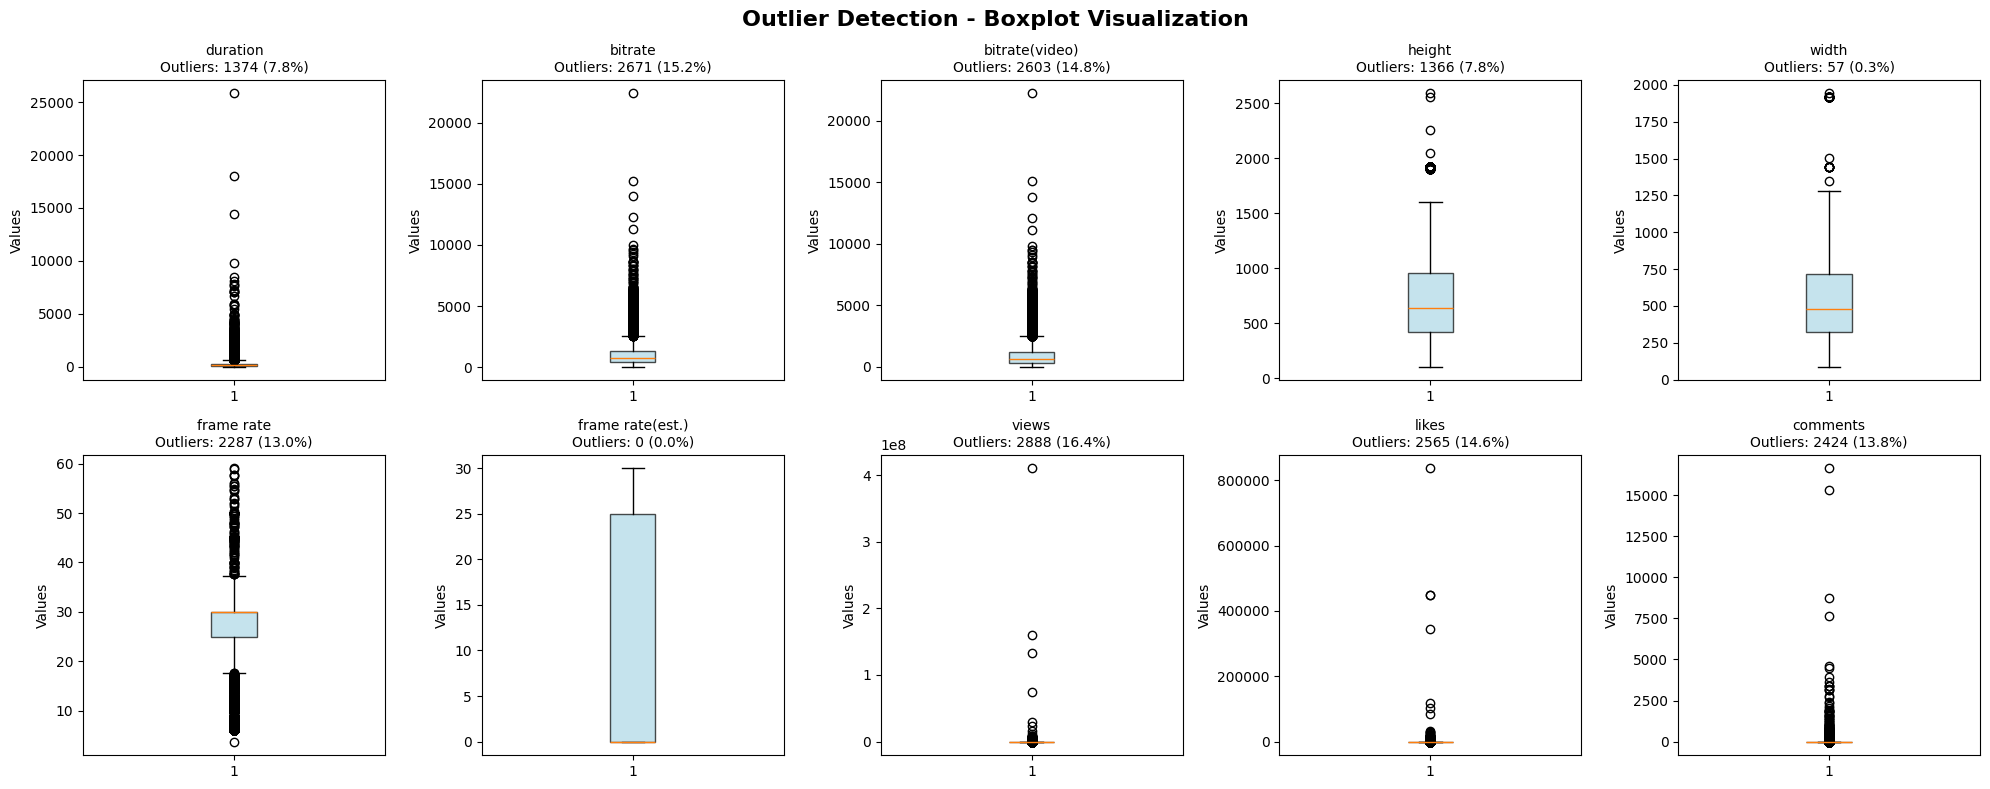

In [5]:
# Visualize outliers - Boxplot
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Outlier Detection - Boxplot Visualization', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    row = idx // 5
    col_idx = idx % 5
    
    ax = axes[row, col_idx]
    
    # Boxplot
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # Thêm outlier count
    outliers_iqr, _, _ = detect_outliers_iqr(df, col)
    ax.set_title(f'{col}\nOutliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}%)', 
                 fontsize=10)
    ax.set_ylabel('Values')

plt.tight_layout()
plt.show()

## 3. Outlier Removal

Xử lý outliers cho các biến có tỷ lệ outliers cao (views, likes, comments).

In [6]:
# Quyết định biến nào cần remove outliers
# Chỉ remove outliers cho views, likes, comments (có outlier % cao)
cols_to_remove_outliers = ['views', 'likes', 'comments']

print("BEFORE Outlier Removal:")
print(f"Total records: {len(df)}")
print(f"Shape: {df.shape}\n")

# Copy dataframe
df_no_outliers = df.copy()

# Remove outliers sử dụng IQR method
for col in cols_to_remove_outliers:
    outliers_iqr, lower, upper = detect_outliers_iqr(df_no_outliers, col)
    
    print(f"\n{col}:")
    print(f"  Outliers detected: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
    print(f"  Range: [{lower:.2f}, {upper:.2f}]")
    
    # Remove outliers
    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)
    ]
    
    print(f"  Records after removal: {len(df_no_outliers)}")

print(f"\nAFTER Outlier Removal:")
print(f"Total records: {len(df_no_outliers)}")
print(f"Shape: {df_no_outliers.shape}")
print(f"Records removed: {len(df) - len(df_no_outliers)} ({(len(df) - len(df_no_outliers))/len(df)*100:.2f}%)")

BEFORE Outlier Removal:
Total records: 17586
Shape: (17586, 15)


views:
  Outliers detected: 2888 (16.42%)
  Range: [-1105.00, 1943.00]
  Records after removal: 14698

likes:
  Outliers detected: 1203 (6.84%)
  Range: [-3.00, 5.00]
  Records after removal: 13495

comments:
  Outliers detected: 1701 (9.67%)
  Range: [0.00, 0.00]
  Records after removal: 11794

AFTER Outlier Removal:
Total records: 11794
Shape: (11794, 15)
Records removed: 5792 (32.94%)


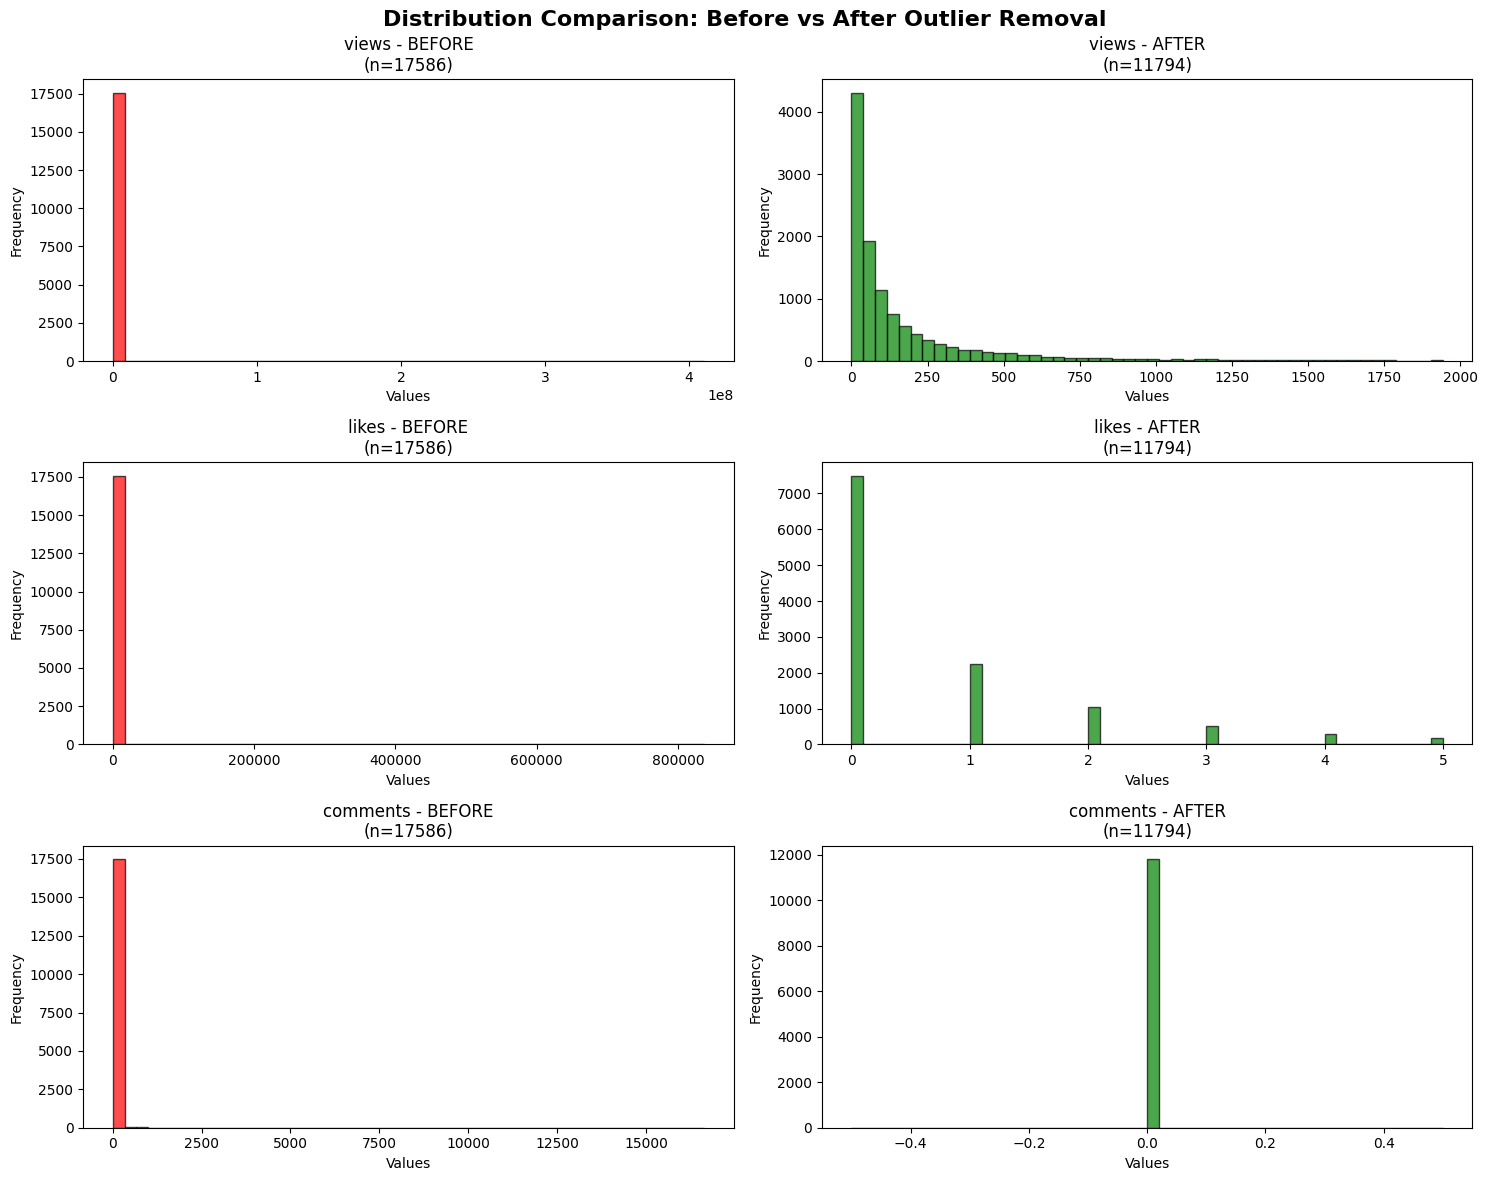

In [7]:
# So sánh phân phối BEFORE vs AFTER
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Distribution Comparison: Before vs After Outlier Removal', fontsize=16, fontweight='bold')

for idx, col in enumerate(cols_to_remove_outliers):
    # Before
    ax1 = axes[idx, 0]
    ax1.hist(df[col], bins=50, alpha=0.7, color='red', edgecolor='black')
    ax1.set_title(f'{col} - BEFORE\n(n={len(df)})', fontsize=12)
    ax1.set_xlabel('Values')
    ax1.set_ylabel('Frequency')
    
    # After
    ax2 = axes[idx, 1]
    ax2.hist(df_no_outliers[col], bins=50, alpha=0.7, color='green', edgecolor='black')
    ax2.set_title(f'{col} - AFTER\n(n={len(df_no_outliers)})', fontsize=12)
    ax2.set_xlabel('Values')
    ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [8]:
# So sánh thống kê Before vs After
comparison = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std', 'Skewness', 'Kurtosis'],
})

for col in cols_to_remove_outliers:
    comparison[f'{col} (Before)'] = [
        df[col].mean(),
        df[col].median(),
        df[col].std(),
        df[col].skew(),
        df[col].kurtosis()
    ]
    comparison[f'{col} (After)'] = [
        df_no_outliers[col].mean(),
        df_no_outliers[col].median(),
        df_no_outliers[col].std(),
        df_no_outliers[col].skew(),
        df_no_outliers[col].kurtosis()
    ]

comparison.round(2)

,Metric,views (Before),views (After),likes (Before),likes (After),comments (Before),comments (After)
0,Mean,68953.34,186.88,208.90,0.68,12.90,0.0
1,Median,153.00,68.00,1.00,0.00,0.00,0.0
2,Std,3537792.77,298.96,8478.23,1.13,225.86,0.0
3,Skewness,97.61,2.92,75.60,1.91,49.28,0.0
4,Kurtosis,10653.82,9.65,6439.71,3.29,3119.21,0.0


In [9]:
# Save cleaned data
df_no_outliers.to_csv('data/youtube_no_outliers_clean.csv', index=False)

**Normality Tests:**
- Hầu hết biến **không có phân phối chuẩn** (p-value < 0.05)
- Views, likes, comments có phân phối highly skewed

**Outlier Removal:**
- Loại bỏ outliers cho: views, likes, comments
- Giữ nguyên các biến technical (duration, bitrate, height, width, frame rate)
- Data sau khi xử lý: **youtube_no_outliers_clean.csv**

**Next Steps:**
- Correlation Analysis với data đã clean
- ANOVA Analysis để so sánh giữa các category